In [ ]:
import os
import gc
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
from srlib.dataset.loading import load_edsr_dataset
from srlib.dataset.visualization import plot_patch_pairs
from srlib.deep_learning.edsr import EDSR
from srlib.constants import (
    CLASS_LABELS_PATH,
    EDSR_PATCH_SIZE,
    EDSR_SCALE_FACTOR,
    EDSR_STRIDE,
    HR_ROOT,
    LR_ROOT,
)

In [2]:
X_train, Y_train, X_val, Y_val, X_test, Y_test = load_edsr_dataset(
    HR_ROOT,
    LR_ROOT,
    CLASS_LABELS_PATH,
    patch_size=EDSR_PATCH_SIZE,
    stride=EDSR_STRIDE,
    scale_factor=EDSR_SCALE_FACTOR,
)


 EDSR dataset | patch 48, stride 48, x2
  images    358 indexed -> 358 kept -> 289 train / 33 val / 36 test


  patches   7,225 train / 825 val / 900 test   of 48 x 48 x 3
  memory    0.97 GB
  range     X [0.0000, 1.0000]   Y [0.0000, 1.0000]
  done in 4.1s



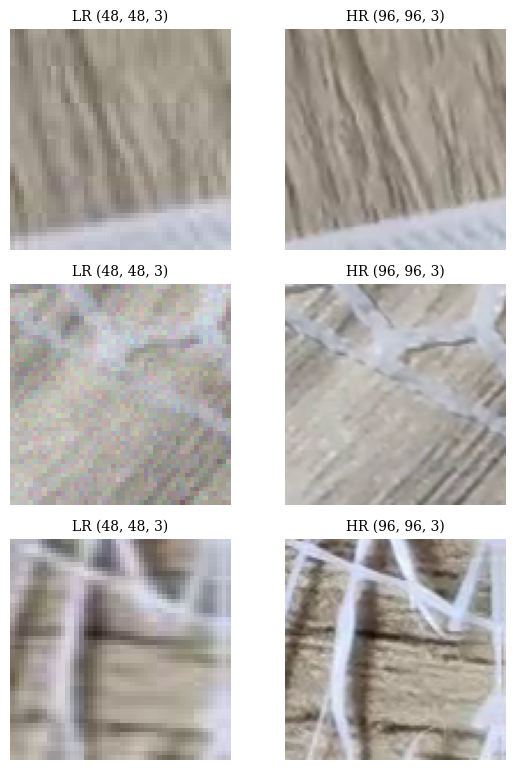

In [3]:
# What the model is actually fed: the LR patch and the HR patch it must
# reconstruct, whose side is EDSR_SCALE_FACTOR times larger.
_ = plot_patch_pairs(X_train, Y_train, count=3, seed=0)

In [4]:
model = EDSR()

model.setup_model(
    scale_factor=EDSR_SCALE_FACTOR, 
    num_res_blocks=16, 
    num_filters=64, 
    learning_rate=5e-5
)

Model: "EDSR"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv2d (Conv2D)                (None, None, None,   1792        ['input[0][0]']                  
                                64)                                                               
                                                                                                  
 conv2d_1 (Conv2D)              (None, None, None,   36928       ['conv2d[0][0]']                 
                                64)                                                            

In [5]:
# Train EDSR and capture callbacks for metrics
history, time_cb, mem_cb = model.fit(
    X_train, Y_train, X_val, Y_val, 
    batch_size=16, 
    epochs=300
)

Training on GPU: /physical_device:GPU:0
Epoch 1/300
452/452 [==============================] - 37s 71ms/step - loss: 0.1534 - psnr: 17.4674 - ssim: 0.3370 - val_loss: 0.0662 - val_psnr: 21.5409 - val_ssim: 0.4827 - lr: 5.0000e-05 - epoch_time_sec: 36.6833 - gpu_mean_current_mb: 968.5402 - gpu_peak_mb: 1426.5608
Epoch 2/300
452/452 [==============================] - 32s 70ms/step - loss: 0.0601 - psnr: 22.4345 - ssim: 0.4891 - val_loss: 0.0632 - val_psnr: 22.1475 - val_ssim: 0.4611 - lr: 5.0000e-05 - epoch_time_sec: 31.5084 - gpu_mean_current_mb: 1077.0911 - gpu_peak_mb: 1505.9912
Epoch 3/300
452/452 [==============================] - 32s 70ms/step - loss: 0.0518 - psnr: 23.8269 - ssim: 0.5480 - val_loss: 0.0513 - val_psnr: 24.0823 - val_ssim: 0.5635 - lr: 5.0000e-05 - epoch_time_sec: 31.5083 - gpu_mean_current_mb: 1077.0911 - gpu_peak_mb: 1505.9302
Epoch 4/300
452/452 [==============================] - 31s 70ms/step - loss: 0.0485 - psnr: 24.4800 - ssim: 0.5659 - val_loss: 0.0500 - val

In [ ]:
del X_train, Y_train, X_val, Y_val  # Free memory
gc.collect()  # Force garbage collection to free memory

1488

In [7]:
# Evaluates the run, saves the checkpoint and the metrics under one
# timestamp, so the reporting notebooks resolve a single run.
timestamp, run_dir, metrics = model.evaluate_and_save(
    X_test, Y_test, history, time_cb, mem_cb,
)


 EDSR run 20260911_134153
  evaluating on the test partition
29/29 [==============================] - 2s 45ms/step - loss: 0.0312 - psnr: 28.7766 - ssim: 0.7819
Loss: 0.0312, PSNR: 28.78 dB, SSIM: 0.7819
Model saved to c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\EDSR\EDSR_20260911_134153\EDSR_x2_20260911_134153.h5
  metrics    -> c:\Users\bgmanuel\MasterInteligenciaArtificial\Periodo2\TFM\Super-Resolution-Images-for-3D-Printing-Defect-Detection\models\EDSR\EDSR_20260911_134153\EDSR_20260911_134153_metrics.pkl
  done in 2.1s

